# Week 4: Greeks
This notebook covers the concept of Greeks in options trading-- the rates of change affecting how traders hedge their funds. 

This uses concepts from the past weeks where:
* **Week 1** focused on the random walk of stock prices-- which was used in the delta hedging table
* **Week 3** showed us how Black-Scholes-Merton trades continuously, whereas in
* **Week 4** now shows us that continuous trades is prohibitively expensive and that is where greeks would help in determining how often trades are made, etc.

In [41]:
from scipy.stats import norm
from math import log, sqrt, exp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define inputs
s_0 = 49
k = 50
r = 0.05
T = 20/52
sigma = 0.20
option_type = 'c'

# Generate 300 posible final stock prices
stock_prices = np.linspace(0.5 * s_0, 1.5 * s_0, 300)

## Greeks Definitions

1. **Delta** is the rate of change in option price given a small change in stock price
2. **Gamma** is the rate of change in delta given a small change in stock price
    * It is usually used to determine how often a stock must be hedged as it tracks how often delta is changing
3. **Theta** is the rate of change in the value of a portffolio over a small period of time. 
    * It is usually called the time decay of a portfolio
4. **Vega** is the rate of change in an options value given a small change in volatility
    * It is used for computing the implied volatility of a given stock

Note: The below functions are using finite differences; which will be more useful for computing greeks of options other than european put/calls.

In [42]:
# Function for d1 and d2
def d_1(sigma, s_0, k, r, T):
    d_1 = (log(s_0/k)+(r+(sigma**2)/2)*T)/((sigma)*sqrt(T))
    return d_1

def d_2(sigma, s_0, k, r, T): 
    return d_1(sigma, s_0, k, r, T) - (sigma)*sqrt(T)

# Pricer (european put/call)
def bsm(sigma, s_0, k, r, T, option_type):
    if option_type == "c":
        d1 = d_1(sigma, s_0, k, r, T)
        d2 = d_2(sigma, s_0, k, r, T)
        opt_price = s_0 * norm.cdf(d1) - k * exp(-r * T) * norm.cdf(d2)
    elif option_type == "p":
        d1 = d_1(sigma, s_0, k, r, T)
        d2 = d_2(sigma, s_0, k, r, T)
        opt_price = k * exp(-r * T) * norm.cdf(-d2) - s_0 * norm.cdf(-d1)
    else:
        return "Acceptable option type input: C or P"
    return opt_price

# Compute for delta prices
def compute_delta(S):
    h = S * 0.005
    up = bsm(sigma, S + h, k, r, T, option_type)
    down = bsm(sigma, S - h, k, r, T, option_type)
    return (up - down)/(2 * h)

# Compute for gamma
def compute_gamma(S):
    h = S * 0.005
    price = bsm(sigma, S, k, r, T, option_type)
    up = bsm(sigma, S + h, k, r, T, option_type)
    down = bsm(sigma, S - h, k, r, T, option_type)
    return (up - 2 * price + down)/(h ** 2)

# Compute for theta
def compute_theta(S):
    h = min(1/365, T * 0.005)
    price = bsm(sigma, S, k, r, T, option_type)
    down = bsm(sigma, S, k, r, T - h, option_type)
    return (down - price)/h

# Compute for vega
def compute_vega(S):
    h = max(0.01, sigma * 0.005)
    up = bsm(sigma + h, S, k, r, T, option_type)
    down = bsm(sigma - h, S, k, r, T, option_type)
    return (up - down)/(2 * h)

## Greek Formulas for European Put/Call

1. Delta
$$\Delta\text{(call)} = N(d_1)$$
$$\text{or}$$
$$\Delta\text{(put)} = N(d_1) - 1$$

2. Gamma
$$\frac{N'(d_1)}{S_0\sigma\sqrt{T}}$$

3. Theta
$$\Theta\text{call} = -\frac{S_0 N'(d_1)\sigma}{2\sqrt{T}}-rKe^{-rT}N(d_2)$$
$$\text{or}$$
$$\Theta\text{put} = -\frac{S_0 N'(d_1)\sigma}{2\sqrt{T}}+rKe^{-rT}N(-d_2)$$

4. Vega
$$ \nu = S_0 \sqrt{T}N'(d_1) $$

5. Change in portfolio value given delta, gamma, and theta
$$\Delta\Pi = \Theta\Delta t + \frac{1}{2} \Gamma\Delta S^2$$

## Relationship of Delta to an Option price curve

Delta is the slope of the option price curve at any given stock price. The curve itself is nonlinear — it bends more steeply as the stock moves toward and past the strike. The tangent line at the current stock price  approximates how much the option price moves for a small change in , which is exactly what delta measures. The gap between the tangent line and the actual curve is where gamma lives — the larger the gap, the more delta is changing, and the more frequently the hedge needs rebalancing.

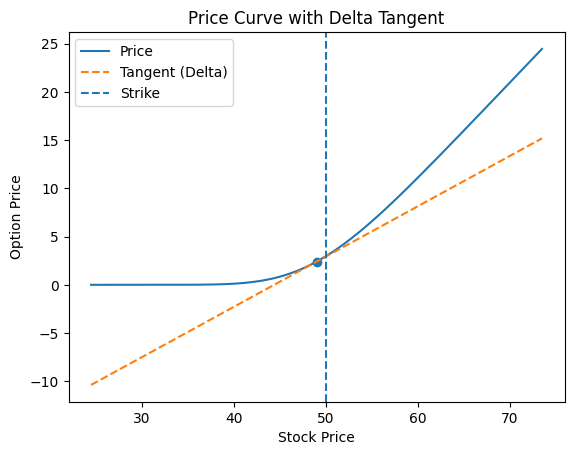

In [43]:
# Compute plot points
prices = [bsm(sigma, S, k, r, T, option_type) for S in stock_prices]

# Compute tangent line
S0 = s_0
h = S0 * 0.005
V0 = bsm(sigma, S0, k, r, T, option_type)
d0 = compute_delta(S0)
tangent = [V0 + d0 * (S - S0) for S in stock_prices]

# Plot the price curve
plt.figure()
plt.plot(stock_prices, prices, label="Price")

# Tangent line
plt.plot(stock_prices, tangent, linestyle='--', label="Tangent (Delta)")

# Highlight point
plt.scatter([S0], [V0])

# Strike line
plt.axvline(x=k, linestyle='--', label='Strike')

plt.title("Price Curve with Delta Tangent")
plt.xlabel("Stock Price")
plt.ylabel("Option Price")
plt.legend()
plt.show()

### Delta as a Slope
The tangent line at  shows delta visually — it’s the instantaneous slope of the price curve at that point. The gap between the tangent and the actual curve is where gamma lives. The wider the gap, the more delta is changing, and the more often the hedge needs rebalancing.

## What the Greeks Are Telling You
Gamma, theta, and vega all peak at the money — ATM options are the most sensitive to everything. Deep ITM or OTM options are relatively inert.

Gamma and vega have identical shapes for calls and puts. Only delta and theta differ between the two, which is put-call parity showing up in the Greeks: $$\Delta _\text{call}-\Delta _\text{put} = 1$$

The gamma-theta plot shows their natural tradeoff — long gamma means you benefit from large moves but bleed theta daily. You can’t have one without paying for the other.

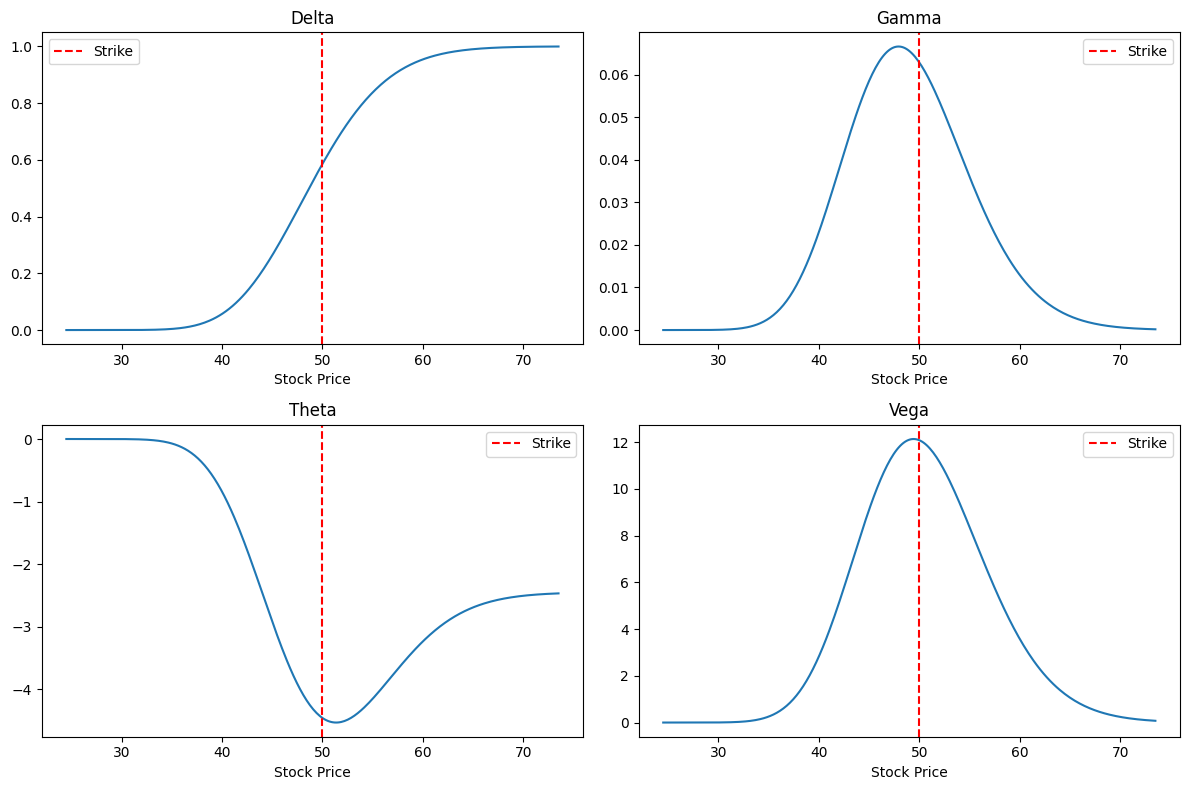

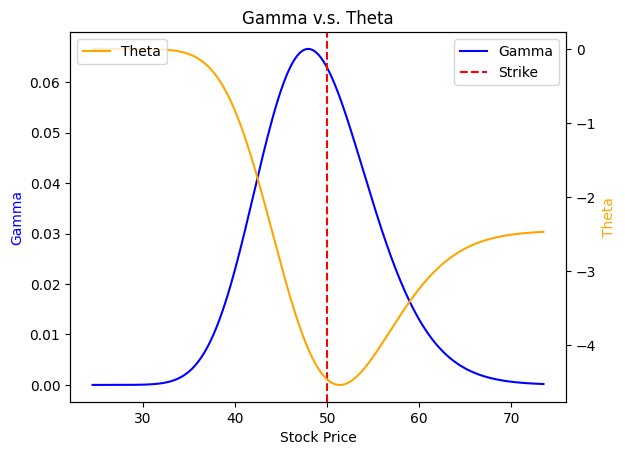

In [44]:
# Compute greeks
deltas =[compute_delta(S) for S in stock_prices]
gammas = [compute_gamma(S) for S in stock_prices]
thetas = [compute_theta(S) for S in stock_prices]
vegas = [compute_vega(S) for S in stock_prices]

# Plot the greek values
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0, 0].plot(stock_prices, deltas)
axes[0, 0].set_title("Delta")
axes[0, 0].set_xlabel("Stock Price")
axes[0, 0].axvline(x=k, color='red', linestyle='--', label='Strike')
axes[0, 0].legend()

axes[0, 1].plot(stock_prices, gammas)
axes[0, 1].set_title("Gamma")
axes[0, 1].set_xlabel("Stock Price")
axes[0, 1].axvline(x=k, color='red', linestyle='--', label='Strike')
axes[0, 1].legend()

axes[1, 0].plot(stock_prices, thetas)
axes[1, 0].set_title("Theta")
axes[1, 0].set_xlabel("Stock Price")
axes[1, 0].axvline(x=k, color='red', linestyle='--', label='Strike')
axes[1, 0].legend()

axes[1, 1].plot(stock_prices, vegas)
axes[1, 1].set_title("Vega")
axes[1, 1].set_xlabel("Stock Price")
axes[1, 1].axvline(x=k, color='red', linestyle='--', label='Strike')
axes[1, 1].legend()

plt.tight_layout()

# Visualise gamma vs theta graphs
fig, ax1 = plt.subplots()

ax1.plot(stock_prices, gammas, color='blue', label="Gamma")
ax1.set_xlabel("Stock Price")
ax1.set_ylabel("Gamma", color='blue')
ax1.axvline(x=k, color='red', linestyle='--', label='Strike')

ax2 = ax1.twinx()

ax2.plot(stock_prices, thetas, color='orange', label="Theta")
ax2.set_ylabel("Theta", color='orange')

ax1.legend(loc='upper right')
ax2.legend(loc='upper left')
plt.title('Gamma v.s. Theta')
plt.show()

## Delta hedging table

Delta hedging simulates what a trader actually does in practice: at each time step, rebalance the stock position to match the current delta. The table below tracks one GBM-simulated path over 20 weeks, showing how shares are bought and sold each week to maintain delta neutrality. The final cumulative cost — net of any exercise revenue — converges to the BSM theoretical premium, regardless of whether the option expires in or out of the money. This is the central result of Hull’s Chapter 19: dynamic hedging costs exactly what the model says the option is worth.

In [45]:
def compute_delta_hedge(sigma, S, k, r, T_remaining):
    if T_remaining <= 0:
        return 1.0 if S > k else 0.0
    return norm.cdf(d_1(sigma, S, k, r, T_remaining))

# BSM call pricer only
def bsm(sigma, s_0, k, r, T):
    d1 = d_1(sigma, s_0, k, r, T)
    d2 = d_2(sigma, s_0, k, r, T)
    opt_price = s_0 * norm.cdf(d1) - k * exp(-r * T) * norm.cdf(d2)
    return opt_price

# Defining inputs
mu = 0.13
n_weeks = 20
n_options = 100000
dt = 1/52 # weekly hedge time

# Compute options cost with BSM:
bsm_price = bsm(sigma, s_0, k, r, n_weeks * dt) * n_options

# Generate random stock prices over the course of n-weeks
np.random.seed(0)
stock_prices = [s_0]
for t in range(n_weeks):
    dS = stock_prices[-1] * (mu * dt + sigma * np.random.normal() * sqrt(dt))
    stock_prices.append(stock_prices[-1] + dS)

# Compute delta based on weekly stock prices
T = n_weeks / 52
deltas = [compute_delta_hedge(sigma, S, k, r, T - t * dt) for t, S in enumerate(stock_prices)]

# Compute stocks purchased hedged against options bought
shares = [deltas[0] * n_options]
shares += [(deltas[t] - deltas[t-1]) * n_options for t in range(1, len(deltas))]

# Cost of shares purchased
cost = [shares[t] * S for t, S in enumerate(stock_prices)]

# Cumulative cost and interest computation
cum_cost = []
interest = []
for t in range (len(cost)):
    int_cost = cost[t] * r * dt if t < n_weeks else 0 # interest on week's spend
    if t == 0:
        cum_cost.append(cost[0] + int_cost)
    else:
        new_cum = cum_cost[t-1] + cost [t] + int_cost
        cum_cost.append(new_cum)
    interest.append(int_cost)

# Create the delta hedge table
rows = []
for week in range(n_weeks + 1):
    rows.append({
        "week": week,
        "stock_price": stock_prices[week],
        "delta": deltas[week],
        "shares_purchased": shares[week],
        "cost_shares_purchased_($000)": cost[week]/1000,
        "cumulative_cost_($000)": cum_cost[week]/1000,
        "interest_cost__($000)": interest[week]/1000
    })

pd.options.display.float_format = '{:.2f}'.format
df = pd.DataFrame(rows)

# Display output
print(df)
if stock_prices[-1] > k:
    delta_hedge = cum_cost[-1] - (k * n_options)
else:
    delta_hedge = cum_cost[-1]
scenario = "ITM (Exercised)" if stock_prices[-1] > k else "OTM (Expired Worthless)"
print(f"Scenario: {scenario}")
print(f"Cost of Hedging: {delta_hedge: .2f}")
print(f"Cost of options using BSM: {bsm_price: .2f}")
print(f"Hedging Error: {abs(delta_hedge - bsm_price):.2f}")
print(f"As % of BSM: {abs(delta_hedge - bsm_price)/bsm_price*100:.1f}%")

    week  stock_price  delta  shares_purchased  cost_shares_purchased_($000)  \
0      0        49.00   0.52          52160.47                       2555.86   
1      1        51.52   0.68          15537.08                        800.47   
2      2        52.22   0.72           4044.23                        211.19   
3      3        53.77   0.80           8088.20                        434.89   
4      4        57.24   0.92          12299.57                        704.09   
5      5        60.35   0.97           5250.89                        316.91   
6      6        58.87   0.96          -1343.77                        -79.11   
7      7        60.57   0.98           2142.15                        129.74   
8      8        60.46   0.98            227.12                         13.73   
9      9        60.44   0.99            282.38                         17.07   
10    10        61.28   0.99            642.01                         39.34   
11    11        61.68   1.00            